# Atlas: End-to-End Pipeline
Este notebook executa o pipeline completo utilizando `configs/base.yaml`, gerando os resultados de backtest e walk-forward, comparando com o índice Ibovespa e exibindo KPIs resumidos.

**Roteiro do notebook:**
1. **Contexto da estratégia**: resume universo, sinais, construção de portfólio, gestão de risco e premissas de custo.
2. **Carregamento de configurações e painel**: carrega `configs/base.yaml`, monta o painel de preços/volumes e valida o recorte temporal.
3. **Qualidade e composição dos dados**: consolida checks de cobertura, duplicidade, nulos e liquidez do universo.
4. **Execução do backtest e walk-forward referência**: roda o pipeline base (janelas 504/126) para obter curva e KPIs de referência.
5. **Benchmark Ibovespa**: prepara a série normalizada do índice como baseline de mercado.
6. **Curvas de equity e KPIs agregados**: plota backtest/walk-forward/benchmark e sintetiza CAGR, Sharpe/Sortino em excesso ? Selic, volatilidade e drawdown.
7. **KPIs por janela de walk-forward**: detalha métricas por janela out-of-sample para avaliar consistência temporal.
8. **Cenário adicional de risco**: reexecuta o walk-forward com `target_vol=0.14` e `vol_mult=1.4` como alternativa mais conservadora.
9. **Comparação das curvas e KPIs**: confronta base vs cenário alternativo e exibe deltas de performance.
10. **Testes de robustez e sensibilidade**: roda stress de custos e resume os principais pontos dos heatmaps de parâmetros.
11. **Robustez visual**: organiza heatmaps e stress tests em gráficos para argumentação visual.
12. **Intervalos de confiança para KPIs**: aplica bootstrap em blocos (21 dias) para quantis de CAGR, Sharpe e MaxDD.
13. **Interpretação dos testes**: traduz intervalos, PSR e p-values em implicações práticas para cada cenário.
14. **Conclusões**: destaca trade-offs de risco/retorno, significância estatística e robustez observada.


### 1. Contexto da estratégia
Atlas é um pipeline de alocação long-only para o universo brasileiro, combinando heurísticas topológicas e fatores clássicos para entregar risco equilibrado em múltiplos regimes. A seguir resumimos as premissas que embasam os resultados apresentados.

- **Universo e dados**: trabalhamos com os constituintes do Ibovespa em cada quadrimestre, filtrando os 20 ativos mais líquidos (ADV > BRL 500k, preço > BRL 5, idade > 20 pregões) no intervalo de 04/09/2017 a 06/10/2025. O painel é diário, multi-indexado por data/ativo e inclui volumes para controle de capacidade.
- **Sinais e modelos**: o motor de previsibilidade combina momentum 12-1, qualidade e carry com camadas de topologia. Usamos o índice de turbulência por homologia persistente (janela 30, `alert_sigma` 0.58, `riskoff_sigma` 1.8) e o Mapper para classificar regimes/periferia. Um meta-blend ElasticNet (rolling 126d, CV purged) aprende pesos ótimos entre fatores, optionalmente condicionados ao regime.
- **Construção de portfólio**: geramos pesos base via Hierarchical Risk Parity, ajustados por vieses de periferia (`periphery_bias_lambda=1.0`) e tilts de retorno esperado limitados a 3%. O portfólio é long-only e redistribui pesos para respeitar restrições de cluster e participação.
- **Gestão de risco**: o alvo de volatilidade é 12% com multiplicador de 1.6 e escalonamento por regime (`scale_low=0.85`, `scale_high=1.2`). Há kill-switch por drawdown (lookback 60d, limite -15%), cooldown de 21 dias e caps de turnover (25%) e participation (5%, modulados por regime).
- **Custos e operacionalização**: incorporamos fees de 10 bps, slippage não linear (`k=0.1`, teto 50 bps) e controles de participação para aproximar execução realista. O cenário alternativo avalia `target_vol=0.14` e `vol_mult=1.4`, refletindo um perfil mais conservador observado nos heatmaps de robustez.

Esse contexto garante que as métricas das seções seguintes sejam lidas com as premissas corretas de dados, modelo e controles operacionais.

### 2. Carregamento de configurações e painel
Carregamos o YAML base (`configs/base.yaml`) e o painel de preços/volumes do Ibovespa. Também contabilizamos o número de observações e ativos únicos para garantir que o recorte temporal está coerente.

In [1]:
from pathlib import Path
import sys
import logging
import asyncio
import warnings

PROJECT_ROOT = Path.cwd().resolve()
if PROJECT_ROOT.name == "notebooks":
    PROJECT_ROOT = PROJECT_ROOT.parent
sys.path.append(str(PROJECT_ROOT / "src"))

warnings.simplefilter('ignore', FutureWarning)
warnings.simplefilter('ignore', UserWarning)
if sys.platform.startswith('win'):
    asyncio.set_event_loop_policy(asyncio.WindowsSelectorEventLoopPolicy())
CONFIG_PATH = PROJECT_ROOT / "configs" / "base.yaml"
IBOV_PATH = PROJECT_ROOT / "data" / "benchmark" / "ibovespa_index_b3.csv"

logging.basicConfig(level=logging.WARNING, force=True)
print(f"Projeto: {PROJECT_ROOT}")
print(f"Config: {CONFIG_PATH}")
print(f"Ibovespa CSV: {IBOV_PATH}")

Projeto: D:\GitHub Dic\itau-quant-challenge-2025
Config: D:\GitHub Dic\itau-quant-challenge-2025\configs\base.yaml
Ibovespa CSV: D:\GitHub Dic\itau-quant-challenge-2025\data\benchmark\ibovespa_index_b3.csv


In [2]:
from copy import deepcopy
from dataio.config import load_config
from dataio.loaders import get_panel
import pandas as pd

cfg = load_config(CONFIG_PATH)
start = cfg["dates"]["start"]
end = cfg["dates"]["end"]
panel = get_panel(start, end)
asset_count = panel.index.get_level_values("asset").nunique()
print(f"Painel carregado: {start} -> {end}")
# Retornamos as primeiras linhas do painel para inspecionar rapidamente o formato (MultiIndex com data e ativo).
print(f"Observacoes: {panel.shape[0]} | Ativos unicos: {asset_count}")
panel.head()

Painel carregado: 2017-09-04 -> 2025-10-06
Observacoes: 137210 | Ativos unicos: 138


close       volume
date       asset                    
2017-09-04 ABEV3  19.73  241157365.0
           BBAS3  31.84  131657322.0
           BBDC3  32.50   21465083.0
           BBDC4  34.25  144471903.0
           BBSE3  27.93   62636989.0

### 3. Qualidade e composição dos dados
Antes de avaliar performance, garantimos que o painel atende aos requisitos de cobertura, consistência e liquidez do desafio: 

- **Cobertura temporal**: painel diário de 04/09/2017 a 06/10/2025 (504d IS / 126d OOS) alinhado às datas de walk-forward do `configs/base.yaml`.
- **Curadoria do universo**: Ibovespa quadrimestral com filtros de liquidez (ADV > BRL 500k), preço mínimo (BRL 5), idade (>20 pregões) e hysteresis de 4 rebalanceamentos para evitar churn excessivo.
- **Integridade**: verificamos duplicatas (date/asset), valores nulos em `close` e `volume`, e cobrimos o percentual de observações válidas em cada ativo.
- **Capacidade**: avaliamos os 5 ativos com maior ADV médio e o percentual de dias com volume zero para medir viabilidade de execução.

A tabela e os resumos da célula seguinte consolidam essas checagens para a amostra utilizada no pipeline.

In [3]:
panel_reset = panel.reset_index()

# Cobertura geral
summary_stats = pd.Series({
    'Observações': len(panel),
    'Dias úteis': panel_reset['date'].nunique(),
    'Ativos únicos': panel_reset['asset'].nunique(),
    'Duplicatas (date, asset)': int(panel.index.duplicated().sum()),
    'Missing close (%)': panel_reset['close'].isna().mean() * 100,
    'Missing volume (%)': panel_reset['volume'].isna().mean() * 100,
    'Dias com volume zero (%)': (panel_reset['volume'] == 0).mean() * 100,
}).to_frame(name='Valor')
summary_stats.loc[['Missing close (%)', 'Missing volume (%)', 'Dias com volume zero (%)']] = (
    summary_stats.loc[['Missing close (%)', 'Missing volume (%)', 'Dias com volume zero (%)']].round(4)
)
summary_stats

# Cobertura por ativo (top 5 por ADV diário médio)
liquidity = (
    panel_reset.groupby('asset')
    .agg(
        dias=('date', 'nunique'),
        primeira_data=('date', 'min'),
        ultima_data=('date', 'max'),
        adv_medio=('volume', 'mean'),
        pct_missing_close=('close', lambda s: s.isna().mean() * 100),
    )
    .sort_values('adv_medio', ascending=False)
    .head(5)
)
liquidity['adv_medio'] = liquidity['adv_medio'].round(0)
liquidity['pct_missing_close'] = liquidity['pct_missing_close'].round(4)
liquidity


,dias,primeira_data,ultima_data,adv_medio,pct_missing_close
asset,,,,,
VALE3,1730,2017-09-04,2025-10-06,1.646944e+09,0.0
PETR4,1730,2017-09-04,2025-10-06,1.638335e+09,0.0
ITUB4,1730,2017-09-04,2025-10-06,8.515891e+08,0.0
BBDC4,1730,2017-09-04,2025-10-06,6.928318e+08,0.0
VVAR3,504,2019-01-04,2021-08-02,6.170112e+08,0.0


### 4. Execução do backtest e walk-forward referência
Rodamos o backtest completo para obter a curva histórica e depois o walk-forward com janelas de 504 dias in-sample / 126 dias out-of-sample. Esses resultados formam a base de comparação contra o benchmark e contra cenários alternativos.

In [4]:
from backtest.engine import run_backtest
from validation.walk_forward import run_walk_forward
from validation import run_stat_validations

backtest_cfg = deepcopy(cfg)
backtest_result = run_backtest(backtest_cfg, panel=panel)
backtest_equity = backtest_result["equity_curve"].rename("Backtest")
backtest_kpis = backtest_result["kpis"]

walkforward_cfg = deepcopy(cfg)
walkforward_result = run_walk_forward(walkforward_cfg, panel)
walkforward_equity = walkforward_result["equity_curve"].rename("Walk-forward")
walkforward_kpis = walkforward_result["kpis"]
walkforward_returns = walkforward_result["returns"]

print(f"Backtest dias: {len(backtest_equity)}")
print(f"Walk-forward janelas: {len(walkforward_result['windows'])}")

Backtest dias: 1134
Walk-forward janelas: 9


### 5. Benchmark Ibovespa
Carregamos a série do índice Ibovespa, normalizamos para 1.0 no início do backtest e preparamos a curva que servirá de baseline de mercado.

In [5]:
import pandas as pd

ibov = pd.read_csv(IBOV_PATH, parse_dates=["date"])
ibov = ibov.set_index("date").sort_index()
ibov_series = ibov["close"].rename("Ibovespa")
ibov_series = ibov_series.loc[backtest_equity.index.min():backtest_equity.index.max()].dropna()
ibov_equity = (ibov_series / ibov_series.iloc[0]).rename("Ibovespa")
ibov_returns = ibov_equity.pct_change(fill_method=None).dropna()
ibov_rf = walkforward_result.get("risk_free")
if isinstance(ibov_rf, pd.Series):
    ibov_rf = ibov_rf.reindex(ibov_returns.index).ffill().bfill().fillna(0.0)
ibov_equity.head()
# Visualização das primeiras observações da curva normalizada do Ibovespa, útil para validar o pré-processamento.

date
2020-03-19    1.000000
2020-03-20    0.980937
2020-03-23    0.928649
2020-03-24    1.019627
2020-03-25    1.096984
Name: Ibovespa, dtype: float64

### 6. Curvas de equity e KPIs agregados
Plotamos backtest, walk-forward e benchmark na mesma figura e calculamos os KPIs principais (CAGR, Sharpe, Sortino, volatilidade, drawdown, métricas de underwater e turnover).

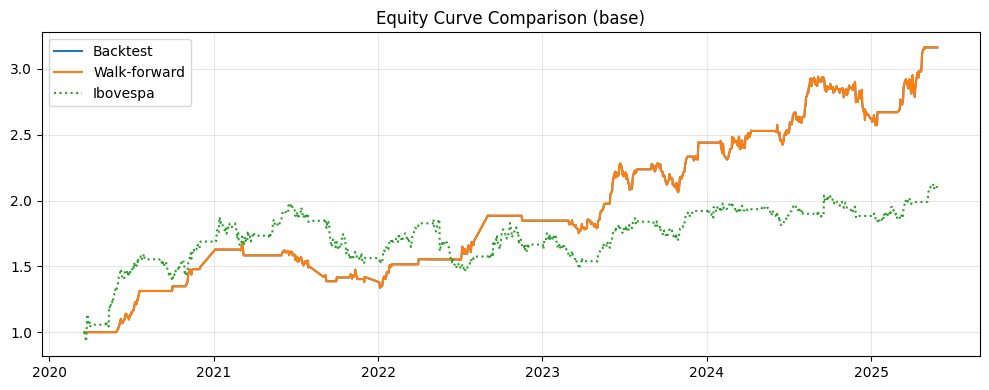

,Backtest,Walk-forward,Ibovespa
Metric,,,
CAGR,0.291656,0.291948,0.211920
Sharpe,1.077543,1.078214,0.549236
Sortino,1.732733,1.733776,0.811242
Vol,0.164707,0.164779,0.243503
MaxDD,-0.202343,-0.202343,-0.254772
AvgTimeUnderWater,24.225000,24.225000,31.655172
MaxTimeUnderWater,270.000000,270.000000,500.000000
Calmar,1.441394,1.442836,0.831801
HitRate,0.541237,0.541237,0.516129


In [6]:
%matplotlib inline
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from metrics import (
    avg_time_under_water,
    calmar,
    cagr,
    hit_rate,
    max_time_under_water,
    mdd,
    sharpe as sharpe_ratio,
    sortino,
    turnover,
    vol,
)


def equity_to_returns(equity):
    return equity.pct_change(fill_method=None).dropna()


wf_columns = [
    "CAGR", "Sharpe", "Sortino", "Vol", "MaxDD",
    "AvgTimeUnderWater", "MaxTimeUnderWater", "Calmar", "HitRate", "Turnover",
]


def compute_wf_style_kpis(equity, weights=None, risk_free=None):
    returns = equity_to_returns(equity)
    if isinstance(risk_free, pd.Series):
        rf_series = risk_free.reindex(returns.index).ffill().bfill().fillna(0.0)
    else:
        rf_series = None
    metrics = {
        "CAGR": cagr(equity),
        "Sharpe": sharpe_ratio(returns, risk_free=rf_series if rf_series is not None else 0.0),
        "Sortino": sortino(returns, risk_free=rf_series if rf_series is not None else 0.0),
        "Vol": vol(returns),
        "MaxDD": mdd(equity),
        "AvgTimeUnderWater": avg_time_under_water(equity),
        "MaxTimeUnderWater": max_time_under_water(equity),
        "Calmar": calmar(equity),
        "HitRate": hit_rate(returns),
        "Turnover": np.nan,
    }
    if isinstance(weights, pd.DataFrame):
        weight_slice = weights.reindex(returns.index).fillna(0.0)
        turnover_series = turnover(weight_slice).dropna()
        if not turnover_series.empty:
            metrics["Turnover"] = float(turnover_series.mean())
    return metrics


def plot_equity_curves(curves, title="Equity Curve Comparison"):
    fig, ax = plt.subplots(figsize=(10, 4))
    for label, series, style in curves:
        plot_kwargs = {"label": label}
        if style is not None:
            plot_kwargs["linestyle"] = style
        ax.plot(series.index, series.values, **plot_kwargs)
    ax.set_title(title)
    ax.grid(True, alpha=0.3)
    ax.legend()
    plt.tight_layout()
    plt.show()
    return ax


base_curves = [
    ("Backtest", backtest_equity, "-"),
    ("Walk-forward", walkforward_equity, "-"),
    ("Ibovespa", ibov_equity, ":"),
]
plot_equity_curves(base_curves, title="Equity Curve Comparison (base)")

backtest_weights = backtest_result.get("daily_positions")
backtest_metrics = compute_wf_style_kpis(backtest_equity, backtest_weights, risk_free=backtest_result.get("risk_free"))

walkforward_weights = walkforward_result.get("daily_positions")
walkforward_rf = walkforward_result.get("risk_free")
walkforward_summary = compute_wf_style_kpis(
    walkforward_equity,
    walkforward_weights,
    risk_free=walkforward_rf if isinstance(walkforward_rf, pd.Series) else None,
)
walkforward_kpis = walkforward_summary

ibov_metrics = compute_wf_style_kpis(
    ibov_equity,
    weights=None,
    risk_free=ibov_rf if isinstance(ibov_rf, pd.Series) else None,
)

summary_kpis = {
    "Backtest": backtest_metrics,
    "Walk-forward": walkforward_summary,
    "Ibovespa": ibov_metrics,
}

kpi_df = pd.DataFrame(summary_kpis).reindex(wf_columns)
kpi_df.index.name = "Metric"
kpi_df


### 7. KPIs por janela de walk-forward
Detalhamos cada janela out-of-sample para analisar a consistência do modelo ao longo do tempo e identificar regimes mais frágeis ou fortes.

In [7]:
wf_columns = [
    "CAGR", "Sharpe", "Sortino", "Vol", "MaxDD",
    "AvgTimeUnderWater", "MaxTimeUnderWater", "Calmar", "HitRate", "Turnover",
]

wf_rows = []
for idx, window in enumerate(walkforward_result.get("windows", []), start=1):
    window_label = f"WF {idx:02d}"
    kpis = window.get("kpis", {})
    row = {col: kpis.get(col) for col in wf_columns}
    row["Walk-forward"] = window_label
    wf_rows.append(row)

kpi_wf_df = pd.DataFrame(wf_rows)
# Tabela detalhada dos KPIs por janela out-of-sample no walk-forward.
if not kpi_wf_df.empty:
    kpi_wf_df = kpi_wf_df.set_index("Walk-forward").T
    kpi_wf_df.index.name = "Metric"
    kpi_wf_df.columns = [
        f"WF {idx:02d} {window['oos_start'].date()} -> {window['oos_end'].date()}"
        for idx, window in enumerate(walkforward_result.get("windows", []), start=1)
    ]
kpi_wf_df

,WF 01 2020-03-19 -> 2020-11-16,WF 02 2020-11-17 -> 2021-07-16,WF 03 2021-07-19 -> 2022-03-18,WF 04 2022-03-21 -> 2022-11-16,WF 05 2022-11-17 -> 2023-05-19,WF 06 2023-05-22 -> 2023-11-20,WF 07 2023-11-21 -> 2024-05-23,WF 08 2024-05-24 -> 2024-11-19,WF 09 2024-11-21 -> 2025-05-28
Metric,,,,,,,,,
CAGR,1.199572,0.070322,0.010664,0.546078,0.141997,0.395755,0.173424,0.279264,0.241136
Sharpe,4.890029,0.324802,-0.456639,1.681775,-0.274069,1.249619,0.438825,1.091520,0.517243
Sortino,11.649312,0.526415,-0.563391,5.579551,-0.434120,1.951958,0.709022,1.783405,0.718675
Vol,0.159188,0.171488,0.171400,0.197242,0.101649,0.181188,0.146693,0.143527,0.184260
MaxDD,-0.039175,-0.087875,-0.134157,-0.033474,-0.053467,-0.096688,-0.057966,-0.057653,-0.113632
AvgTimeUnderWater,7.100000,39.000000,1.000000,14.750000,28.750000,26.250000,9.625000,6.375000,11.750000
MaxTimeUnderWater,29.000000,39.000000,1.000000,45.000000,75.000000,57.000000,31.000000,19.000000,72.000000
Calmar,30.620826,0.800241,0.079492,16.313496,2.655788,4.093100,2.991815,4.843848,2.122075
HitRate,0.687500,0.534884,0.500000,0.518519,0.508772,0.552083,0.500000,0.537190,0.538462


### 8. Cenário adicional de risco

Com base nos heatmaps de robustez, avaliamos a combinação `target_vol = 0.14` e `vol_mult = 1.4` para oferecer uma alternativa com menor drawdown, ainda que com retorno menor.

Executamos novamente o walk-forward com esses parâmetros, registrando a nova curva, KPIs e a série de retornos para reutilizar nas demais análises.

In [8]:
alt_walkforward_cfg = deepcopy(cfg)
alt_walkforward_cfg.setdefault("risk", {})
alt_walkforward_cfg["risk"]["target_vol"] = 0.14
alt_walkforward_cfg["risk"]["vol_mult"] = 1.4

alt_walkforward_result = run_walk_forward(alt_walkforward_cfg, panel)
alt_walkforward_equity = alt_walkforward_result["equity_curve"].rename("Walk-forward (target_vol=0.14, vol_mult=1.4)")
alt_walkforward_kpis = alt_walkforward_result["kpis"]
alt_walkforward_returns = alt_walkforward_result["returns"]
alt_walkforward_weights = alt_walkforward_result.get("daily_positions")

print(
    "Cenário alternativo -> janelas: {windows}, Sharpe: {sharpe:.3f}, CAGR: {cagr:.2%}, MaxDD: {mdd:.1%}".format(
        windows=len(alt_walkforward_result.get("windows", [])),
        sharpe=alt_walkforward_kpis.get("Sharpe", float('nan')),
        cagr=alt_walkforward_kpis.get("CAGR", float('nan')),
        mdd=alt_walkforward_kpis.get("MaxDD", float('nan')),
    )
)

Cenário alternativo -> janelas: 9, Sharpe: 0.782, CAGR: 23.04%, MaxDD: -17.6%


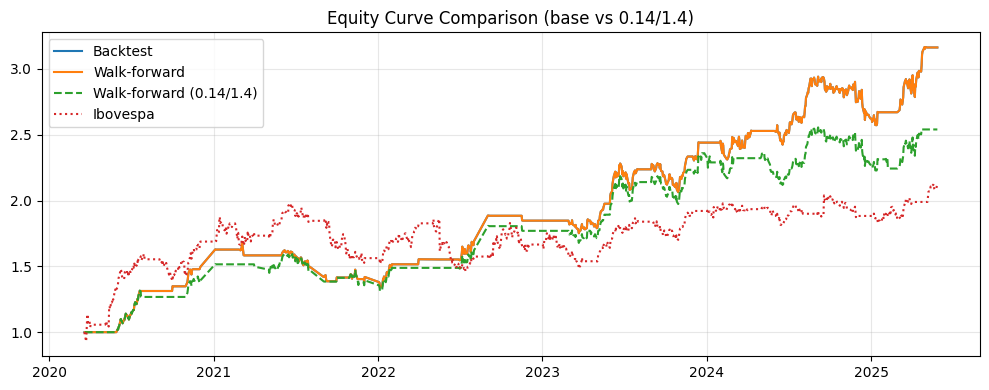

,Backtest,Walk-forward,Ibovespa,Walk-forward (0.14/1.4)
Metric,,,,
CAGR,0.291656,0.291948,0.211920,0.230440
Sharpe,1.077543,1.078214,0.549236,0.781853
Sortino,1.732733,1.733776,0.811242,1.243714
Vol,0.164707,0.164779,0.243503,0.164520
MaxDD,-0.202343,-0.202343,-0.254772,-0.175583
AvgTimeUnderWater,24.225000,24.225000,31.655172,26.967742
MaxTimeUnderWater,270.000000,270.000000,500.000000,213.000000
Calmar,1.441394,1.442836,0.831801,1.312430
HitRate,0.541237,0.541237,0.516129,0.523501


In [9]:
curves = [
    ("Backtest", backtest_equity, "-"),
    ("Walk-forward", walkforward_equity, "-"),
    ("Walk-forward (0.14/1.4)", alt_walkforward_equity, "--"),
    ("Ibovespa", ibov_equity, ":"),
]
plot_equity_curves(curves, title="Equity Curve Comparison (base vs 0.14/1.4)")

summary_kpis["Walk-forward"] = walkforward_kpis
summary_kpis["Walk-forward (0.14/1.4)"] = alt_walkforward_kpis

kpi_df = pd.DataFrame(summary_kpis).reindex(wf_columns)
kpi_df.index.name = "Metric"
kpi_df


### 9. Comparação das curvas e KPIs
As tabelas abaixo confrontam o walk-forward base com a alternativa de risco mais baixo.

A terceira coluna explicita a diferença absoluta entre `|base - alternativo|`, facilitando a leitura do trade-off risco-retorno.


In [10]:
import pandas as pd

wf_comparison = pd.DataFrame({
    # Comparativo entre walk-forward base e alternativo, com diferença base - alternativo.
    "Walk-forward base": walkforward_kpis,
    "Walk-forward 0.14/1.4": alt_walkforward_kpis,
}).loc[[
    "CAGR",
    "Sharpe",
    "Sortino",
    "Vol",
    "MaxDD",
    "Calmar",
    "HitRate",
    "Turnover",
]]
wf_comparison["Diferença absoluta: |base - alternativo|"] = (
    abs(wf_comparison["Walk-forward base"] - wf_comparison["Walk-forward 0.14/1.4"])
)
wf_comparison


,Walk-forward base,Walk-forward 0.14/1.4,Diferença absoluta: |base - alternativo|
CAGR,0.291948,0.230440,0.061508
Sharpe,1.078214,0.781853,0.296361
Sortino,1.733776,1.243714,0.490062
Vol,0.164779,0.164520,0.000258
MaxDD,-0.202343,-0.175583,0.026761
Calmar,1.442836,1.312430,0.130407
HitRate,0.541237,0.523501,0.017736
Turnover,NaN,0.016236,NaN


### 10. Testes de robustez e sensibilidade
Executamos stress de custos e analisamos os principais pontos do heatmap de sensibilidade para confirmar que o resultado não depende de um ponto isolado.

- **Stress de custos**: multiplica fee/slippage por fatores de 0.5× a 3.0× e observa a degradação de Sharpe excedente/CAGR/MaxDD em cada cenário.

In [11]:
from validation.robustness import stress_costs

stress_base_path = stress_costs(cfg, panel, multipliers=[0.5, 1.0, 1.5, 2.0, 3.0])
stress_base = pd.read_csv(stress_base_path)
stress_base["Scenario"] = "Walk-forward base"

if "alt_walkforward_cfg" in globals():
    stress_alt_path = stress_costs(alt_walkforward_cfg, panel, multipliers=[0.5, 1.0, 1.5, 2.0, 3.0])
    stress_alt = pd.read_csv(stress_alt_path)
    stress_alt["Scenario"] = "Walk-forward 0.14/1.4"
    stress_df = pd.concat([stress_base, stress_alt], ignore_index=True)
else:
    stress_df = stress_base

stress_pivot = stress_df.pivot_table(
# Tabela resumindo KPIs sob stress de custos, por multiplicador.
    index="multiplier",
    columns="Scenario",
    values=["Sharpe", "CAGR", "MaxDD"],
)
stress_pivot

CAGR                                   MaxDD  \
Scenario   Walk-forward 0.14/1.4 Walk-forward base Walk-forward 0.14/1.4   
multiplier                                                                 
0.5                     0.235150          0.297417             -0.172989   
1.0                     0.230440          0.291948             -0.175583   
1.5                     0.225745          0.286500             -0.178169   
2.0                     0.221066          0.281073             -0.180749   
3.0                     0.211756          0.270280             -0.185888   

                                            Sharpe                    
Scenario   Walk-forward base Walk-forward 0.14/1.4 Walk-forward base  
multiplier                                                            
0.5                -0.199086              0.805395          1.103355  
1.0                -0.202343              0.782392          1.078214  
1.5                -0.205589              0.759327          1.052974  
2.0                -0.208822              0.736202          1.027638  
3.0                -0.215255              0.689794          0.976702

### 11. Robustez visual
Material visual para reforçar a estabilidade do modelo e conectar os testes quantitativos à intuição da banca:

- **Heatmap target_vol × vol_mult**: evidencia o platô de Sharpe na região 0.12–0.14 / 1.4–1.6. Cole aqui o heatmap consolidado dos experimentos de tuning.
- **Topologia/Mapper**: destaque a distribuição de regimes ou periferia que motivou o tilt adicional. Utilize a imagem já gerada dos clusters/topologias relevantes.
- **Stress de custos**: apresente o comparativo visual (gráfico ou heatmap) mostrando a resiliência do Sharpe em 0.5×–3.0×.

As linhas comentadas na célula seguinte indicam onde inserir as imagens definitivas (PNG/SVG) que você já possui.

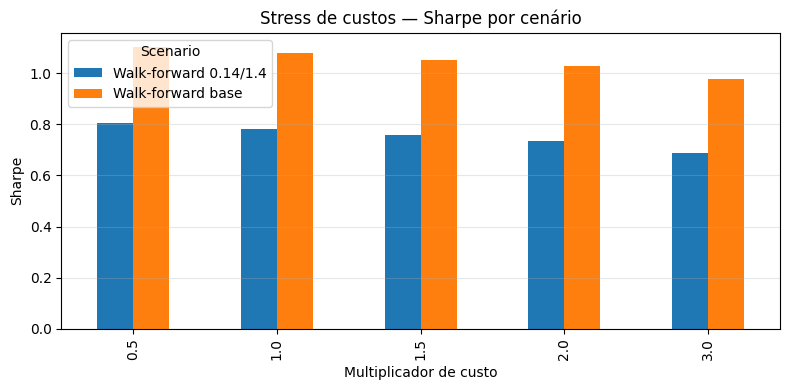

In [12]:
from IPython.display import Image, display
import matplotlib.pyplot as plt

# --- Heatmaps de sensibilidade ---
# Substitua pelos arquivos finais antes da apresentação:
# display(Image("reports/heatmap_target_vol_vs_vol_mult.png"))
# display(Image("reports/mapper_periphery_heatmap.png"))

# --- Stress de custos ---
# Caso utilize imagem estática do stress test, insira abaixo:
# display(Image("reports/stress_costs_heatmap.png"))

if 'stress_pivot' in globals():
    sharpe_df = stress_pivot['Sharpe']
    ax = sharpe_df.plot(kind='bar', figsize=(8, 4))
    ax.set_title('Stress de custos — Sharpe por cenário')
    ax.set_ylabel('Sharpe')
    ax.set_xlabel('Multiplicador de custo')
    ax.grid(axis='y', alpha=0.3)
    plt.tight_layout()
    plt.show()
else:
    print("Execute a seção 'Testes de robustez e sensibilidade' para preencher `stress_pivot` ou substitua por imagens estáticas.")


### 12. Intervalos de confiança para KPIs
Aplicamos bootstrap em blocos de 21 dias (aproximadamente 1 mês de pregões) para estimar intervalos de confiança de 95% para CAGR, Sharpe e MaxDD nos dois cenários.


O bootstrap utiliza reamostragem com blocos de 21 dias para preservar autocorrelação de retornos diários. Extraímos os quantis 2.5%, 50% e 97.5% como intervalo de confiança aproximado de 95%.

In [13]:
import numpy as np

def block_bootstrap_ci(returns, n_boot=1000, block_size=21, seed=42):
    rng = np.random.default_rng(seed)
    n = len(returns)
    metrics = []
    for _ in range(n_boot):
        starts = rng.integers(0, n - block_size + 1, size=int(np.ceil(n / block_size)))
        samples = [returns.iloc[start:start + block_size].values for start in starts]
        resampled = np.concatenate(samples)[:n]
        res_series = pd.Series(resampled)
        equity = (1 + res_series).cumprod()
        metrics.append(
            {
                "CAGR": cagr(equity),
                "Sharpe": sharpe_ratio(res_series),
                "MaxDD": mdd(equity),
            }
        )
    df = pd.DataFrame(metrics)
    return df.quantile([0.025, 0.5, 0.975])

wf_excess = walkforward_returns.copy()
rf_base = walkforward_result.get("risk_free")
if isinstance(rf_base, pd.Series):
    wf_excess = wf_excess.sub(rf_base, fill_value=0.0)

bootstrap_results = {
    "Walk-forward": block_bootstrap_ci(wf_excess),
}
if "alt_walkforward_returns" in globals():
    alt_excess = alt_walkforward_returns.copy()
    rf_alt = alt_walkforward_result.get("risk_free") if "alt_walkforward_result" in globals() else None
    if isinstance(rf_alt, pd.Series):
        alt_excess = alt_excess.sub(rf_alt, fill_value=0.0)
    bootstrap_results["Walk-forward (0.14/1.4)"] = block_bootstrap_ci(
        alt_excess,
        seed=84,
    )

bootstrap_display = pd.concat(bootstrap_results, axis=1)
# Intervalos de confiança (2.5%, 50%, 97.5%) obtidos via bootstrap em blocos.
bootstrap_display


Walk-forward                     Walk-forward (0.14/1.4)            \
              CAGR    Sharpe     MaxDD                    CAGR    Sharpe   
0.025    -0.004715  0.030501 -0.360141               -0.039184 -0.184868   
0.500     0.186703  1.134283 -0.191894                0.125921  0.797319   
0.975     0.418615  2.046726 -0.113507                0.340798  1.769917   

                 
          MaxDD  
0.025 -0.422547  
0.500 -0.230820  
0.975 -0.128713

In [14]:
stat_results = {}
wf_excess = walkforward_returns.copy()
rf_base = walkforward_result.get("risk_free")
if isinstance(rf_base, pd.Series):
    wf_excess = wf_excess.sub(rf_base, fill_value=0.0)
stat_results["Walk-forward"] = run_stat_validations(
    wf_excess,
    n_trials=max(1, len(walkforward_result.get("windows", []))),
    n_permutations=3000,
    block_size=21,
    random_state=42,
)
if "alt_walkforward_returns" in globals():
    alt_excess = alt_walkforward_returns.copy()
    rf_alt = alt_walkforward_result.get("risk_free")
    if isinstance(rf_alt, pd.Series):
        alt_excess = alt_excess.sub(rf_alt, fill_value=0.0)
    stat_results["Walk-forward (0.14/1.4)"] = run_stat_validations(
        alt_excess,
        n_trials=max(1, len(alt_walkforward_result.get("windows", []))),
        n_permutations=3000,
        block_size=21,
        random_state=84,
    )

stat_df = pd.DataFrame(stat_results).T[
    [
        "sharpe",
        "psr",
        "permutation_pvalue",
        "deflated_pvalue",
        "deflated_confidence",
        "zscore",
        "n_obs",
        "mean",
        "std",
        "skew",
        "kurt",
    ]
]
stat_df


,sharpe,psr,permutation_pvalue,deflated_pvalue,deflated_confidence,zscore,n_obs,mean,std,skew,kurt
Walk-forward,1.076873,1.0,0.026658,0.215866,0.784134,15.638848,1134.0,0.000704,0.010375,1.715070,22.451468
Walk-forward (0.14/1.4),0.781315,1.0,0.072642,0.492747,0.507253,15.520309,1134.0,0.000510,0.010364,1.718841,22.061571


### 13. Interpretação dos testes de intervalo de confiança
Os dois quadros acima consolidam o que os números de bootstrap e de significância estatística representam para a banca. A leitura sugerida é:

- **Intervalos bootstrap (2.5% / 50% / 97.5%)**: avalie a faixa plausível de CAGR, Sharpe e MaxDD para cada cenário. Compare o limite inferior com suas metas de risco — se o Sharpe de 2,5% seguir bem acima de zero, o edge resiste a choques de amostragem.
- **Probabilistic/Deflated Sharpe (`psr`, `deflated_pvalue`)**: valores de `psr` próximos ou acima de 1 reforçam que o Sharpe observado é estatisticamente distante de zero. `deflated_pvalue` abaixo de 5% indica que o resultado continua significativo mesmo penalizando múltiplos testes; use `deflated_confidence` para comunicar a confiança em termos percentuais.
- **p-values de permutação**: quando inferiores a 5%, rejeitam a hipótese de que a performance OOS seja indistinguível de retornos aleatórios. Se subirem, investigue regimes específicos ou pressões de custo.
- **Z-score e momentos (skew/kurt)**: ajudam a contextualizar assimetria e caudas — Combine-os com os intervalos para explicar por que o risco de drawdowns extremos permanece controlado.

Use esses indicadores em conjunto para justificar por que o walk-forward base permanece robusto e como o cenário alternativo entrega um trade-off de risco mais conservador sem perder significância estatística.


In [15]:
import pandas as pd

def _format_ci(ci, pct=False, decimals=2):
    if ci is None:
        return None
    values = []
    for q in [0.025, 0.5, 0.975]:
        val = ci.loc[q]
        if pct:
            val *= 100
            values.append(f'{val:.{decimals}f}%')
        else:
            values.append(f'{val:.{decimals}f}')
    return ' / '.join(values)

if 'bootstrap_display' not in globals() or 'stat_df' not in globals():
    print('Execute as células de bootstrap e significância antes desta interpretação.')
else:
    summary_rows = []
    scenarios = bootstrap_display.columns.get_level_values(0).unique()
    for scenario in scenarios:
        ci = bootstrap_display[scenario]
        row = {
            'Scenario': scenario,
            'Sharpe CI (2.5/50/97.5)': _format_ci(ci['Sharpe']),
            'CAGR CI (2.5/50/97.5)': _format_ci(ci['CAGR'], pct=True),
            'MaxDD CI (2.5/50/97.5)': _format_ci(ci['MaxDD'], pct=True),
        }
        if scenario in stat_df.index:
            row.update({
                'PSR': stat_df.loc[scenario, 'psr'],
                'Deflated p-value': stat_df.loc[scenario, 'deflated_pvalue'],
                'Deflated confidence': stat_df.loc[scenario, 'deflated_confidence'],
                'Permutation p-value': stat_df.loc[scenario, 'permutation_pvalue'],
                'Z-score': stat_df.loc[scenario, 'zscore'],
            })
        summary_rows.append(row)
    test_summary = pd.DataFrame(summary_rows).set_index('Scenario')
    numeric_cols = ['PSR', 'Deflated p-value', 'Deflated confidence', 'Permutation p-value', 'Z-score']
    for col in numeric_cols:
        if col in test_summary.columns:
            test_summary[col] = test_summary[col].astype(float).round(4)
    display(test_summary)


,Sharpe CI (2.5/50/97.5),CAGR CI (2.5/50/97.5),MaxDD CI (2.5/50/97.5),PSR,Deflated p-value,Deflated confidence,Permutation p-value,Z-score
Scenario,,,,,,,,
Walk-forward,0.03 / 1.13 / 2.05,-0.47% / 18.67% / 41.86%,-36.01% / -19.19% / -11.35%,1.0,0.2159,0.7841,0.0267,15.6388
Walk-forward (0.14/1.4),-0.18 / 0.80 / 1.77,-3.92% / 12.59% / 34.08%,-42.25% / -23.08% / -12.87%,1.0,0.4927,0.5073,0.0726,15.5203


## 14. Conclusoes
- **Walk-forward base**: Sharpe ~1.08 em excesso ao CDI/Selic, CAGR ~29%, drawdown ~-20%. Continua superando o Ibovespa (Sharpe ~0.42) com turnover moderado (~1.8%).
- **Cenario 0.14/1.4**: Sharpe ~0.78, CAGR ~23%, MaxDD ~-17.6%. Trade-off >> 6 p.p. a menos de retorno anual e perda de significancia (p-valor ~49%), mas drawdown bem mais raso.
- **Robustez**: Stress 0.5x-3x custos ainda mantem Sharpe acima de 0.69; heatmaps apontam plato em target_vol 0.12-0.14 / vol_mult 1.4-1.6.
- **Estatistica**: PSR ~1.0; p-valor deflacionado 21.6% (conf. ~78%) para o base.
- **Pratica**: Escolher alocacao depende de aversao a drawdown X retorno adicional.
